## Simulating data from empirical parameter estimates from Shekhar and Rahnev (2021)

In [30]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.nn import sigmoid
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
from fastprogress import progress_bar
from scipy.stats import spearmanr
import statsmodels.api as sm
import numpy as np
import dill
from matplotlib.backends.backend_pdf import PdfPages

from jax import vmap, lax

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

from hmfc.model import HierarchicalBernoulliLDS
from hmfc.gibbs import gibbs_step
from hmfc.utils import convert_mean_to_std_ig_params
from hmfc.constants import A_MAX


### Load in estimated parameters and data

In [11]:
file_name = '/vsc-hard-mounts/leuven-data/343/vsc34314/Shekhar_2021.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves
        

### Draw emissions and states based on data and estimated parameters from Shekhar

In [12]:
def sample_emissions_states(key,
           inputs,
           w_i,
           a_i,
           sigmasq_i,
           mu_x_i
           ):

    num_subjects, num_trials, num_inputs = inputs.shape

    def _sample_one_subject(key, u_i, w_i, a_i, sigmasq_i, mu_x_i):
        
        k1, k2, k3 = jr.split(key, 3)

        sigmasq0_i = 1.0
        b_i = mu_x_i * (1 - a_i)
        
        # Sample latent states starting at the stationary distribution
        # Stationary covariance is \sigmmu_a^2 = \sigma^2 / (1 - a^2)
        x_i0 = tfd.Normal(mu_x_i, jnp.sqrt(sigmasq0_i)).sample(seed=k1)
  
        def _step(x_it, key):
            x_itp1 = tfd.Normal(a_i * x_it + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
            return x_itp1, x_it
        _, x_i = lax.scan(_step, x_i0, jr.split(k2, num_trials))

        # Sample emissions
        y_i = tfd.Bernoulli(x_i + u_i @ w_i).sample(seed=k3)
        return dict(a=a_i, mu_x=mu_x_i, w=w_i, sigmasq=sigmasq_i), x_i, y_i

    return vmap(_sample_one_subject)(jr.split(key, num_subjects), inputs, w_i, a_i, sigmasq_i, mu_x_i)

In [13]:
burn_in = 250

# Load in Shekhar parameters
a_i = jnp.mean(posterior_samples_a[burn_in:,:], axis=0)
sigmasq_i = jnp.mean(posterior_samples_sigmasq[burn_in:,:], axis=0)
mu_x_i = jnp.mean(posterior_samples_mu_x[burn_in:,:], axis=0)
w_i = jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0)

# Sample states and emissions
key = jr.PRNGKey(0)
true_params, true_states, emissions = sample_emissions_states(key, inputs, w_i, a_i, sigmasq_i, mu_x_i)


In [14]:
true_states.shape

(20, 2799)

### Initialize model


In [15]:
num_iters = 2000

init_mu_a = 0.90
init_sigma_a = 0.1
init_mu_w = jnp.zeros(num_inputs)
init_sigma_w = jnp.repeat(1.0, num_inputs)
init_mu_sigmasq = 3.0
init_beta_sigmasq = 3.0 * 0.3**2
init_sigma_mu_x = 0.5

model = HierarchicalBernoulliLDS(num_inputs, init_mu_a, init_sigma_a, init_mu_w, init_sigma_w, init_mu_sigmasq, init_beta_sigmasq, init_sigma_mu_x)
params, states, _ = model.sample(key, inputs)

In [16]:
states.shape

(20, 2799)

### Fit model

In [17]:
lps = jnp.zeros((num_iters,)) # log probability

posterior_samples_mu_a = jnp.zeros((num_iters,))
posterior_samples_sigma_a = jnp.zeros((num_iters,))
posterior_samples_mu_w = jnp.zeros((num_iters, num_inputs))
posterior_samples_sigma_w = jnp.zeros((num_iters, num_inputs))
posterior_samples_mu_sigmasq = jnp.zeros((num_iters,))
posterior_samples_beta_sigmasq = jnp.zeros((num_iters,))
posterior_samples_sigma_mu_x = jnp.zeros((num_iters,))

posterior_samples_a = jnp.zeros((num_iters, num_subjects))
posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
posterior_samples_mu_x = jnp.zeros((num_iters, num_subjects))

posterior_samples_states = jnp.zeros((num_iters, num_subjects, num_trials))

for itr in progress_bar(range(num_iters)):

    this_key, key = jr.split(key)
    lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model)
    
    lps = lps.at[itr].set(lp)

    posterior_samples_mu_a = posterior_samples_mu_a.at[itr].set(sigmoid(model.logit_mu_a))
    posterior_samples_sigma_a = posterior_samples_sigma_a.at[itr].set(jnp.exp(model.log_sigma_a))
    posterior_samples_mu_w = posterior_samples_mu_w.at[itr].set(model.mu_w)
    posterior_samples_sigma_w = posterior_samples_sigma_w.at[itr].set(jnp.exp(model.log_sigma_w))
    posterior_samples_mu_sigmasq = posterior_samples_mu_sigmasq.at[itr].set(jnp.exp(model.log_mu_sigmasq))
    posterior_samples_beta_sigmasq = posterior_samples_beta_sigmasq.at[itr].set(jnp.exp(model.log_beta_sigmasq))
    posterior_samples_sigma_mu_x = posterior_samples_sigma_mu_x.at[itr].set(jnp.exp(model.log_sigma_mu_x))


    posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
    posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
    posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
    posterior_samples_mu_x = posterior_samples_mu_x.at[itr].set(params['mu_x'])
    
    posterior_samples_states = posterior_samples_states.at[itr].set(states)

### Save the data

In [18]:
file_name = '/vsc-hard-mounts/leuven-data/343/vsc34314/Shekhar_simulations.dil'

list_of_variable_names = ("lps", 
  "posterior_samples_mu_a", "posterior_samples_sigma_a",
  "posterior_samples_mu_sigmasq", "posterior_samples_beta_sigmasq",
  "posterior_samples_mu_w", "posterior_samples_sigma_w",
  "posterior_samples_sigma_mu_x", "posterior_samples_mu_x",
  "posterior_samples_a","posterior_samples_sigmasq",
  "posterior_samples_w", "posterior_samples_states")


with open(file_name, 'wb') as file:
    dill.dump(list_of_variable_names, file)  # Store all the names first
    
    for variable_name in list_of_variable_names:
        dill.dump(eval(variable_name), file) # Store the objects themselves

### Load the data

In [ ]:
file_name = '/vsc-hard-mounts/leuven-data/343/vsc34314/Shekhar_simulations.dil'

g = globals()
with open(file_name,'rb') as file:
    list_of_variable_names = dill.load(file)  # Get the names of stored objects
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)    # Get the objects themselves

### Log prob

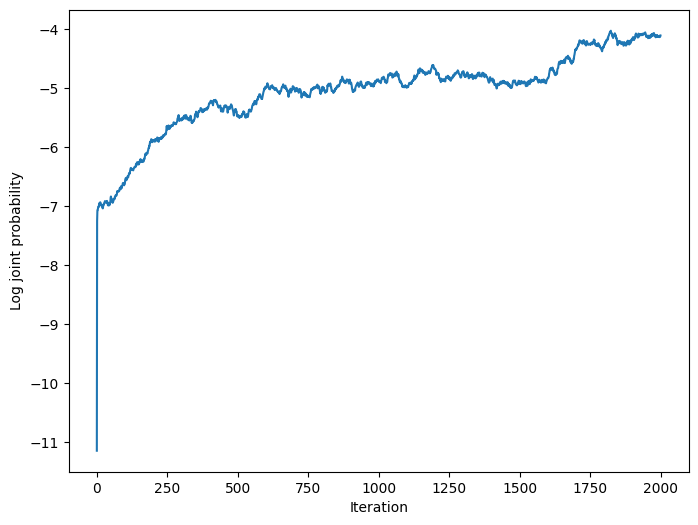

In [19]:
burn_in = 250 # choose a different value informed by the plot below

plt.figure(figsize=(8, 6))
plt.plot(jnp.stack(lps)/emissions.size) # normalized log joint prob
plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
plt.show()

### Compare true and inferred estimates of mu_x_i averaged over iterations

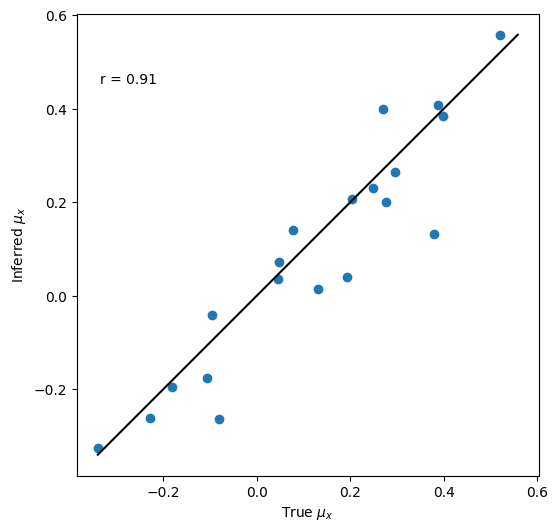

In [20]:
# Compute posterior mean of mu_x_i for each subject over iterations
posterior_mean_mu_x = jnp.mean(posterior_samples_mu_x[burn_in:], axis=0)

mu_x_min = min(true_params['mu_x'].min(), posterior_mean_mu_x.min())
mu_x_max = max(true_params['mu_x'].max(), posterior_mean_mu_x.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['mu_x'], posterior_mean_mu_x)
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xlabel("True $\mu_x$")
plt.ylabel("Inferred $\mu_x$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['mu_x'], posterior_mean_mu_x)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
plt.show()

### Compare true and inferred estimates of a_i averaged over iterations

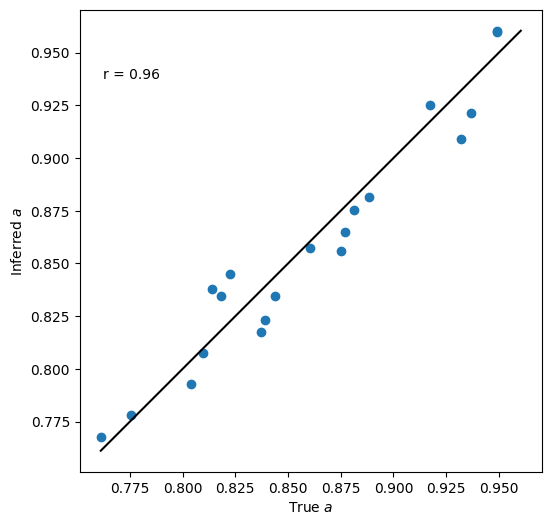

In [21]:
# Compute posterior mean of a_i for each subject over iterations
posterior_mean_a = jnp.mean(posterior_samples_a[burn_in:], axis=0)

a_min = min(true_params['a'].min(), posterior_mean_a.min())
a_max = max(true_params['a'].max(), posterior_mean_a.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['a'], posterior_mean_a)
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$")
plt.ylabel("Inferred $a$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['a'], posterior_mean_a)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
plt.show()

### Compare true and inferred estimates of sigmasq_i averaged over iterations

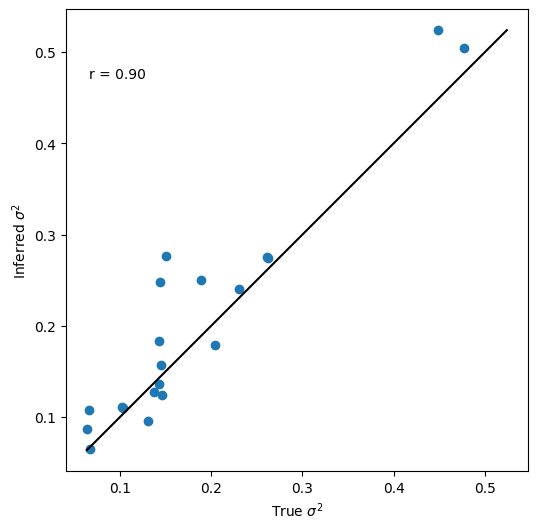

In [22]:
# Compute posterior mean of sigmasq_i for each subject over iterations
posterior_mean_sigmasq = jnp.mean(posterior_samples_sigmasq[burn_in:], axis=0)

sigmasq_min = min(true_params['sigmasq'].min(), posterior_mean_sigmasq.min())
sigmasq_max = max(true_params['sigmasq'].max(), posterior_mean_sigmasq.max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['sigmasq'], posterior_mean_sigmasq)
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xlabel("True $\sigma^2$")
plt.ylabel("Inferred $\sigma^2$")
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['sigmasq'], posterior_mean_sigmasq)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
plt.show()

### Compare true and inferred estimates of w_i averaged over iterations

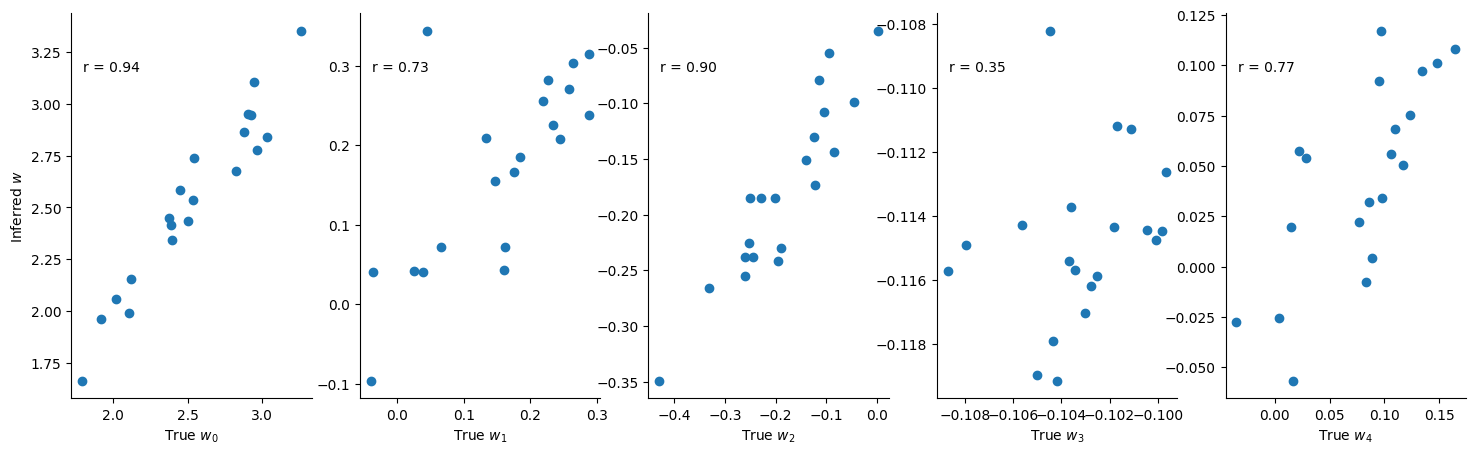

In [23]:
w_min = min(true_params["w"].min(), jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0).min())
w_max = max(true_params["w"].max(), jnp.mean(posterior_samples_w[burn_in:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=False, figsize=(18, 5))

for d, ax in enumerate(axs):
    ax.scatter(true_params["w"][:, d], jnp.mean(posterior_samples_w[burn_in:,:,d], axis=0))
    ax.set_xlabel(r"True $w_{:d}$".format(d))
    if d == 0:
        ax.set_ylabel(r"Inferred $w$".format(d))
    #ax.plot([w_min, w_max], [w_min, w_max], '-k')
    #ax.set_aspect(1.0)
    r, p = spearmanr(true_params["w"][:, d], jnp.mean(posterior_samples_w[burn_in:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
    sns.despine()



### Correlation between inferred and fitted criterion trajectories over all subjects

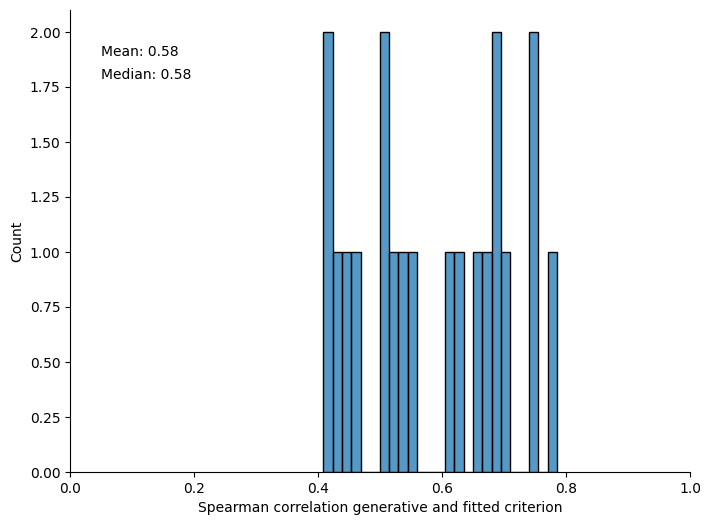

In [24]:
posterior_samples_states_mean = jnp.mean(posterior_samples_states[burn_in:,:,:], axis=0) 
posterior_samples_states_std = jnp.std(posterior_samples_states[burn_in:,:,:], axis=0)

correlations_inferred_and_fitted_states = jnp.array([spearmanr(true_states[subject], posterior_samples_states_mean[subject])[0] for subject in range(num_subjects)])

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

plt.figure(figsize=(8, 6))
sns.histplot(correlations_inferred_and_fitted_states, bins=25)
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction')
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.85), xycoords='axes fraction')
plt.xlabel('Spearman correlation generative and fitted criterion')
plt.ylabel('Count')
plt.xlim(0, 1)
sns.despine()
plt.show()


### Correlation between inferred and fitted criterion trajectories per subject

In [39]:
posterior_samples_states_std.shape

(20, 2799)

In [34]:
with PdfPages('estimated_criterion_fluct_Shekhar.pdf') as pdf:
    for subject in range(num_subjects):
      
        plt.figure(figsize=(8, 6))
        plt.plot(true_states[subject][:trial_limit], label="True states", linewidth=2, color='red', alpha=.6)
        plt.plot(posterior_samples_states_mean[subject][:trial_limit], label="Inferred states", linewidth=2.5)
        plt.fill_between(jnp.arange(trial_limit), #95% CI
                  posterior_samples_states_mean[subject, :trial_limit] - 2 * posterior_samples_states_std[subject, :trial_limit],
                  posterior_samples_states_mean[subject, :trial_limit] + 2 * posterior_samples_states_std[subject, :trial_limit], color='r', alpha=0.25)
        plt.xlabel("Trial")
        plt.ylabel("Criterion $x_t$")
        plt.title(r"Subject {:d}".format(subject))
        plt.legend(loc='lower right')
        r, p = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
        rmse = jnp.sqrt(jnp.mean((true_states[subject]-posterior_samples_states_mean[subject])**2))
        plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
        plt.annotate('rmse = {:.2f}'.format(rmse), xy=(0.05, 0.85), xycoords='axes fraction')
        sns.despine()
        
        pdf.savefig()
        plt.close()

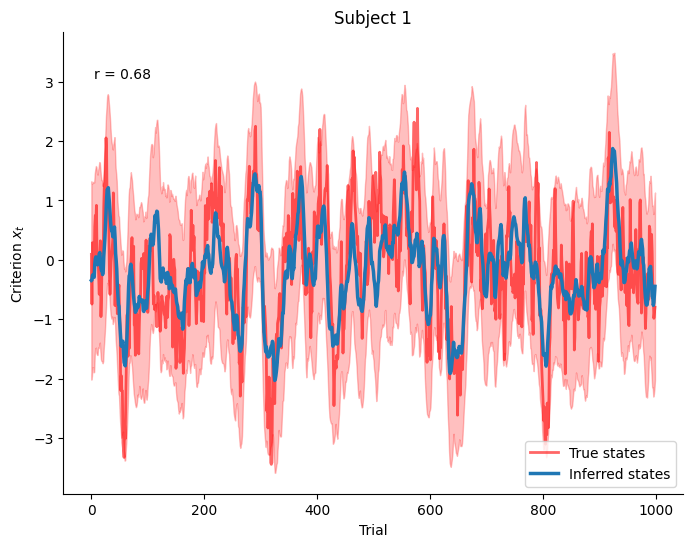

In [28]:
subject = 1
trial_limit = 1000

plt.figure(figsize=(8, 6))
plt.plot(true_states[subject][:trial_limit], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(posterior_samples_states_mean[subject][:trial_limit], label="Inferred states", linewidth=2.5)
plt.fill_between(jnp.arange(trial_limit), #95% CI
          posterior_samples_states_mean[subject, :trial_limit] - 2 * posterior_samples_states_std[subject, :trial_limit],
          posterior_samples_states_mean[subject, :trial_limit] + 2 * posterior_samples_states_std[subject, :trial_limit], color='r', alpha=0.25)
plt.xlabel("Trial")
plt.ylabel("Criterion $x_t$")
plt.title(r"Subject {:d}".format(subject))
plt.legend(loc='lower right')
r, p = spearmanr(true_states[subject], posterior_samples_states_mean[subject])
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
sns.despine()


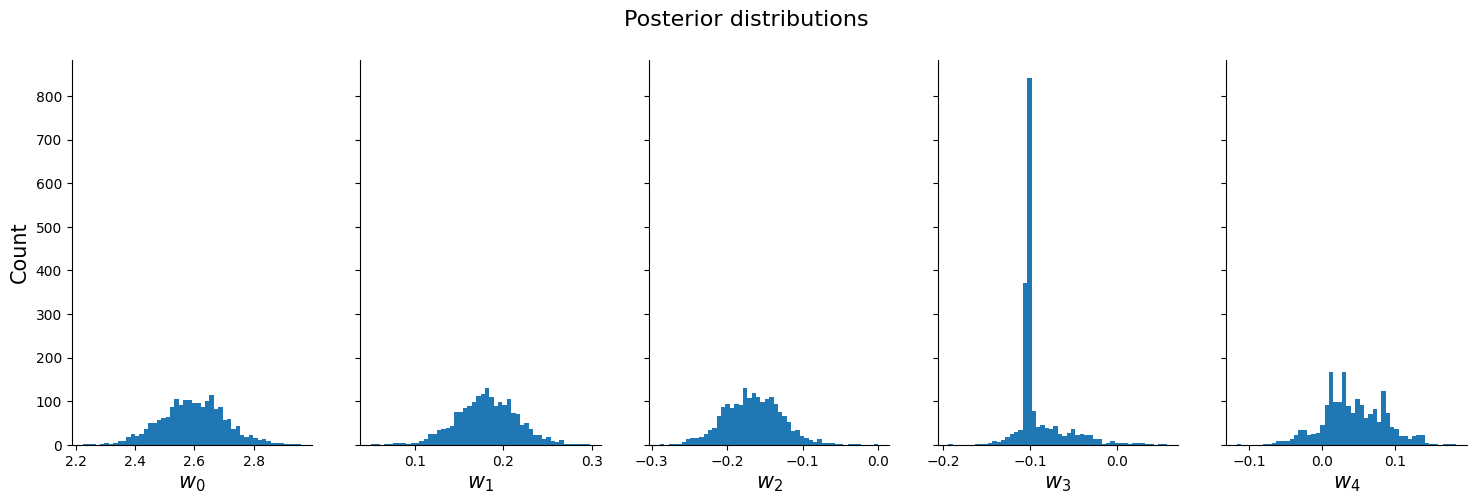

In [67]:
fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(18, 5))
fig.suptitle("Posterior distributions", fontsize=16)
for d, ax in enumerate(axs):
    ax.hist(posterior_samples_mu_w[burn_in:, d], bins=50)
    if d == 0:
        ax.set_ylabel("Count", fontsize=15)
    ax.set_xlabel(r"$w_{:d}$".format(d), fontsize=15)
    sns.despine()

In [ ]:
fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5), dpi=600)
        fig.suptitle("Posterior distributions", fontsize=16)
        fig.text(0.5, 0.93, "Dataset {:d}".format(dataset), ha='center', va='top', fontsize=12)
        
        sd_true_per_subject_w = jnp.std(all_true_params[dataset]['w'], axis=0)
        for d, ax in enumerate(axs):
            ax.hist(all_posterior_samples_sigma_w[dataset][burn_in:, d], bins=30)
            ax.axvline(x=true_sigma_w[d], color='black')
            ax.axvline(x=sd_true_per_subject_w[d], color='red')
            if d == 0:
                ax.set_ylabel("Count", fontsize=15)
            ax.set_xlabel(r"$\sigma_{{w_{:d}}}$".format(d), fontsize=15)